In [1]:
import sys
import pandas as pd
from pathlib import Path
from torch.utils.data import DataLoader

BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(BASE_DIR))

from src import (
    # train_and_apply_cascade,  # при обучении
    CascadeImputer,  # при применении
    
    GeophysicalFeatureExtractor,
    DataCleansing,
)

def main():
    BASE_DIR = Path(__file__).resolve().parent
    RAW_DATA_PATH = BASE_DIR / "data" / "raw" / "train.csv"
    PROCESSED_DATA_PATH = BASE_DIR / "data" / "processed" / "train_preprocessed.parquet"
    MODELS_DIR = BASE_DIR / "models" / "imputers"
    
    print(f"Базовая директория: {BASE_DIR}")
    

    print("\n[1/4] Загрузка данных...")
    if not RAW_DATA_PATH.exists():
        raise FileNotFoundError(f"Файл не найден: {RAW_DATA_PATH}")

    raw_df = pd.read_csv(RAW_DATA_PATH, sep=';') 
    
    # print("\n[2/4] Запуск каскадной импутации (CatBoost)...")
    # imputed_df = train_and_apply_cascade(raw_df, models_dir=MODELS_DIR)
    
    print("\n[2/4] Применение каскадной импутации (загрузка готовых моделей)...")
    imputer = CascadeImputer(models_dir=MODELS_DIR)
    imputed_df = imputer.transform(raw_df)
    
    
    print("\n[3/4] Расчет геофизических признаков...")
    geo_extractor = GeophysicalFeatureExtractor()
    df_with_features = geo_extractor.transform(imputed_df)
    
    print("\n[4/4] Очистка и логарифмирование...")
    cleansing = DataCleansing(
        cols_to_drop = [
                    "X_LOC",
                    "Y_LOC",
                    "FORMATION",
                    "RDEP",
                    "SGR",
                    "RMED",
                    "ROP",
                    "PEF",
                    "RSHA",
                    "RXO",
                    "MUDWEIGHT",
                    "DCAL",
                    "RMIC",
                    "ROPA",
                    "WELL",
                    "FORCE_2020_LITHOFACIES_CONFIDENCE",
                ],
        cols_to_log = ['RDEP', 'RMED', 'RSHA']
    )
    final_df = cleansing.transform(df_with_features)
    
    PROCESSED_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
    final_df.to_parquet(PROCESSED_DATA_PATH, index=False)
    print(f"\n Пайплайн завершен! Данные сохранены в: {PROCESSED_DATA_PATH}")

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, f1_score
from catboost import CatBoostClassifier, Pool
from src.pipelines import get_baseline_pipeline
from src.pipelines import get_rf_pipeline

df = pd.read_parquet("/Users/polina/VSCode/ML/Lithology_project/Lithology prediction/data/processed/train_preprocessed.parquet")
df_raw = pd.read_csv('/Users/polina/VSCode/ML/Lithology_project/Lithology prediction/data/raw/train.csv', sep=';')

df['WELL'] = df_raw['WELL'].values

target_col = "FORCE_2020_LITHOFACIES_LITHOLOGY"
service_cols = ["WELL"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(df, groups=df['WELL']))

train_df = df.iloc[train_idx]
val_df = df.iloc[val_idx]

X_train, y_train = train_df.drop(columns=[target_col]), train_df[target_col]
X_val, y_val = val_df.drop(columns=[target_col]), val_df[target_col]

Обучение SGDClassifier baseline >>> 

 Отчет по классификации (Validation):
              precision    recall  f1-score   support

       30000       0.67      0.77      0.72     37982
       65000       0.89      0.82      0.85    176056
       65030       0.40      0.25      0.31     29272
       70000       0.49      0.43      0.46     12431
       70032       0.38      0.68      0.49      2575
       74000       0.04      0.28      0.07       495
       80000       0.39      0.38      0.38     10940
       86000       0.24      0.45      0.32       240
       88000       0.91      0.99      0.95      3899
       90000       0.07      0.76      0.13       514
       93000       0.00      0.00      0.00         0
       99000       0.14      0.79      0.24      1838

    accuracy                           0.72    276242
   macro avg       0.38      0.55      0.41    276242
weighted avg       0.76      0.72      0.73    276242

Модель сохранена в: models/baseline_sgd.joblib


/Users/polina/miniforge3/envs/ml_course/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/polina/miniforge3/envs/ml_course/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/polina/miniforge3/envs/ml_course/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

Матрица ошибок сохранена в: reports/figures/baseline/confusion_matrix.png


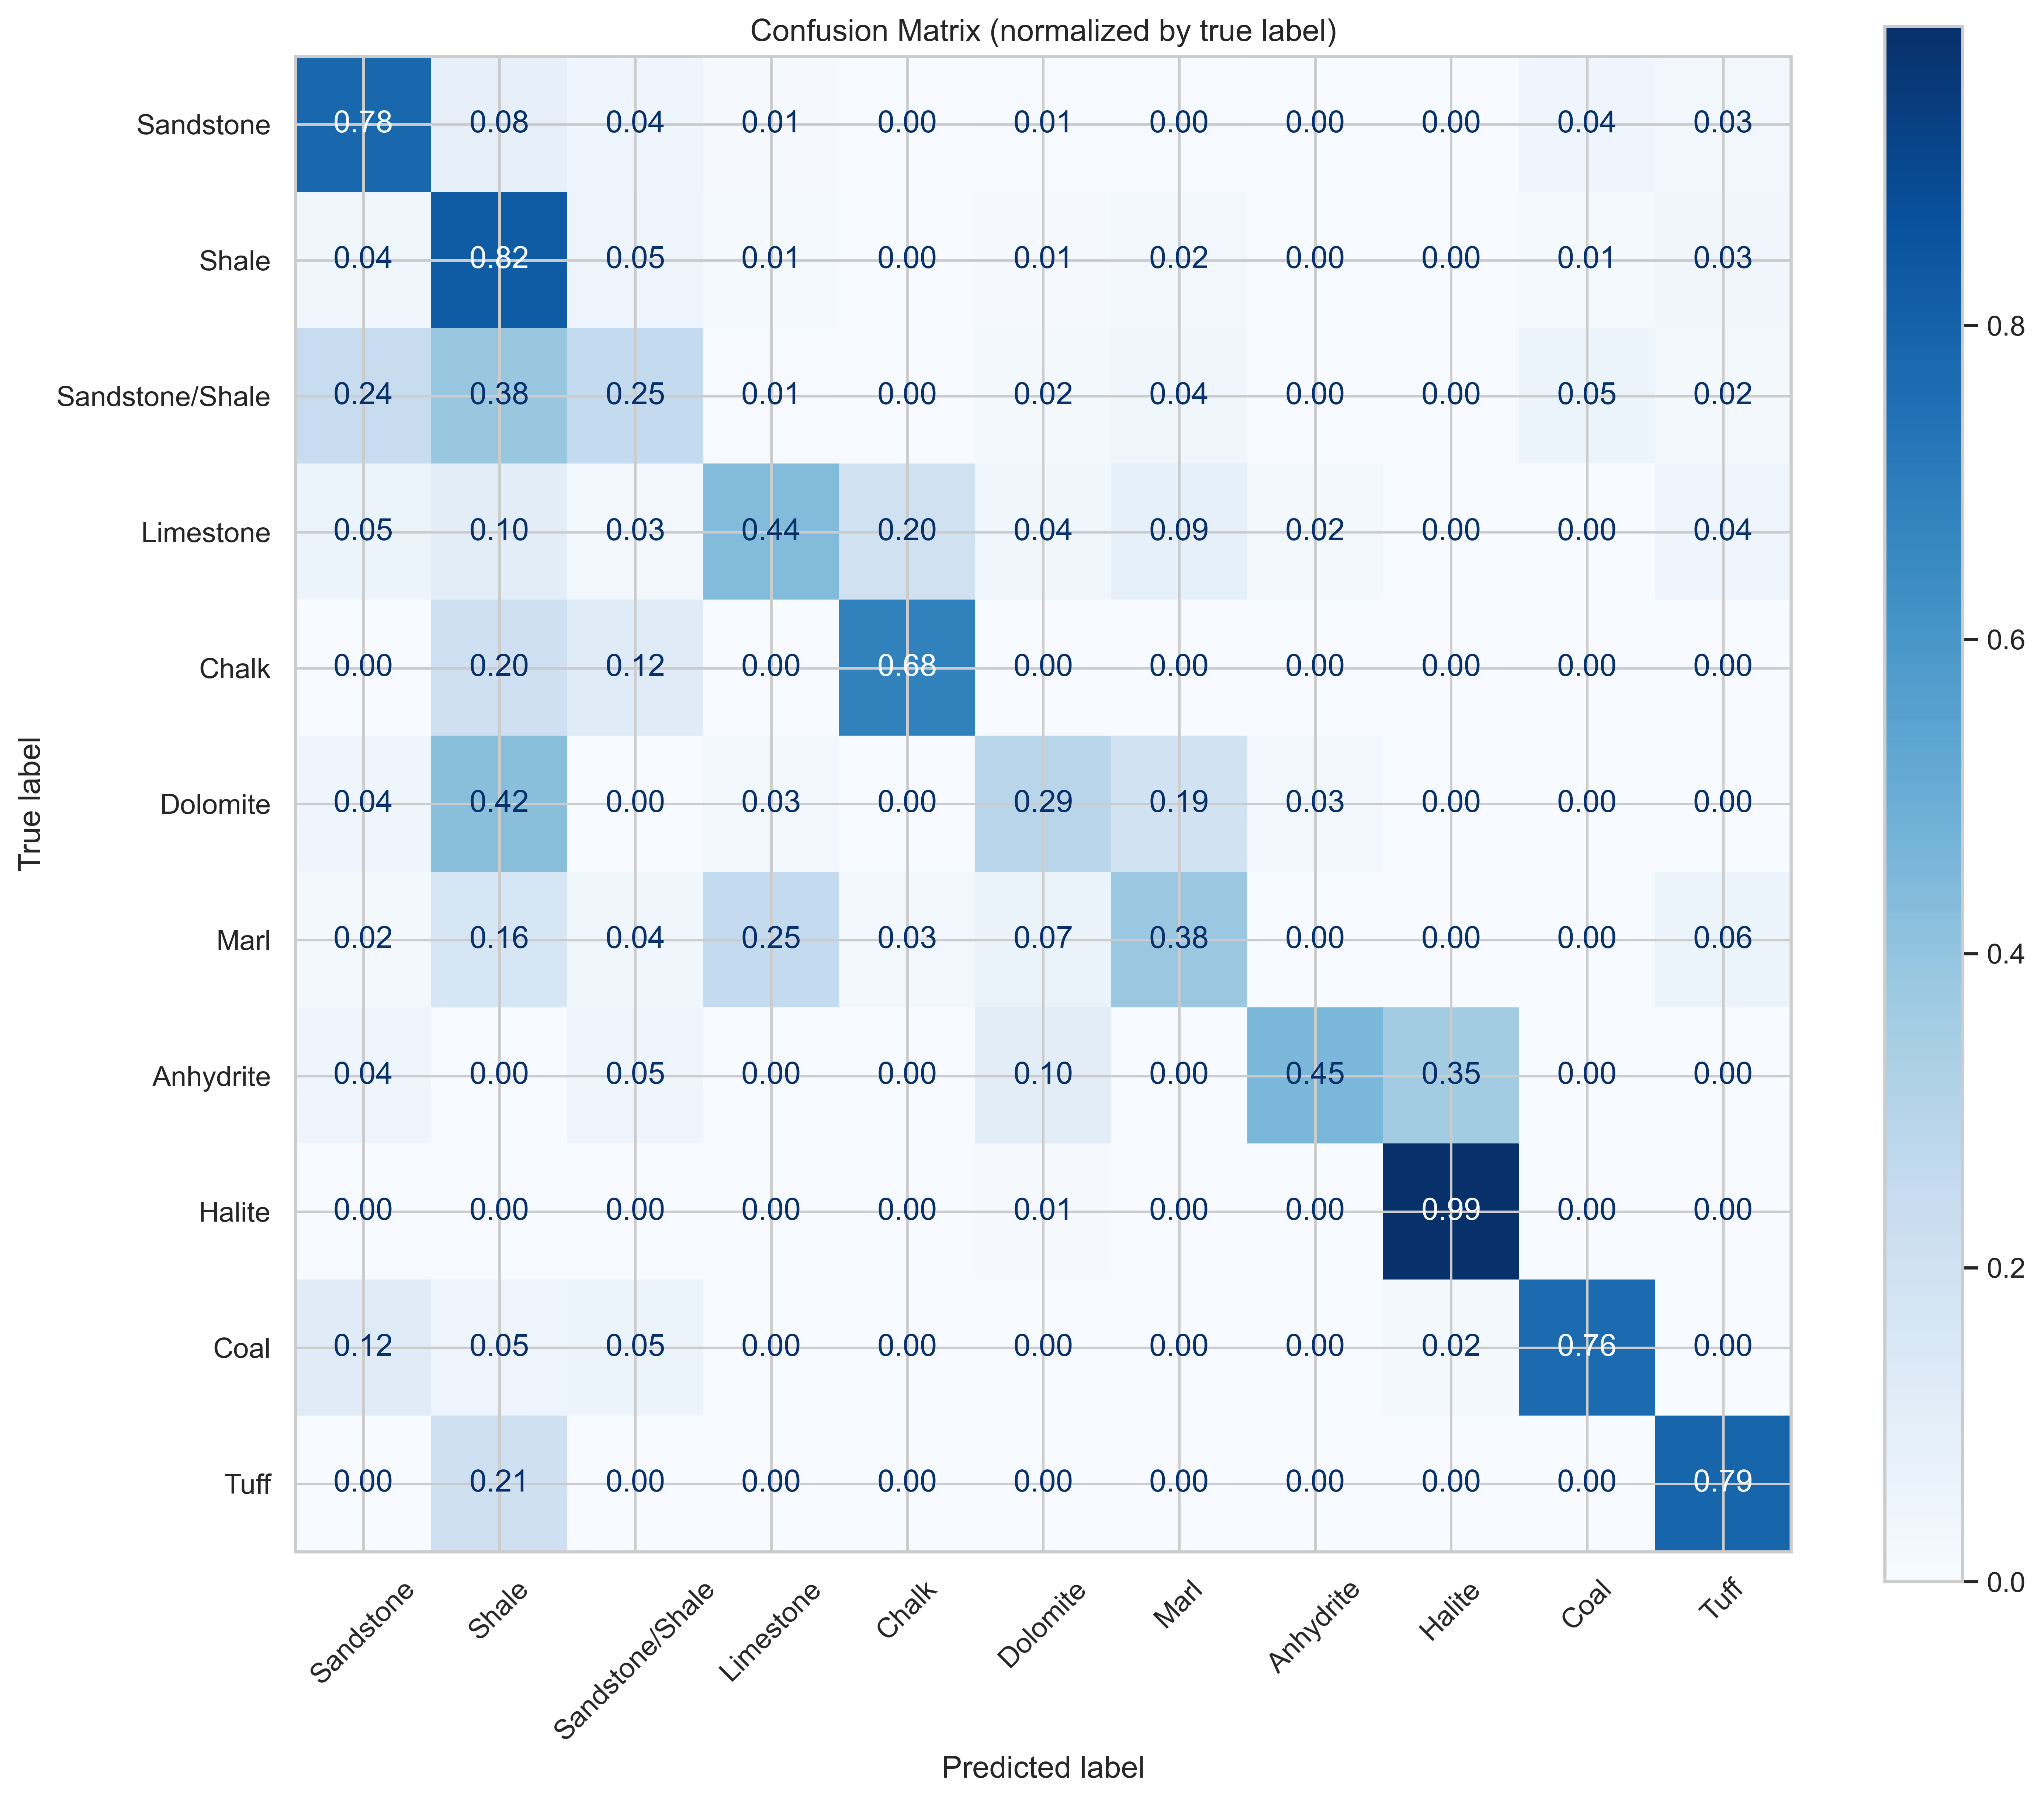

ROC-AUC графики сохранены в: reports/figures/baseline/roc_auc_curves.png


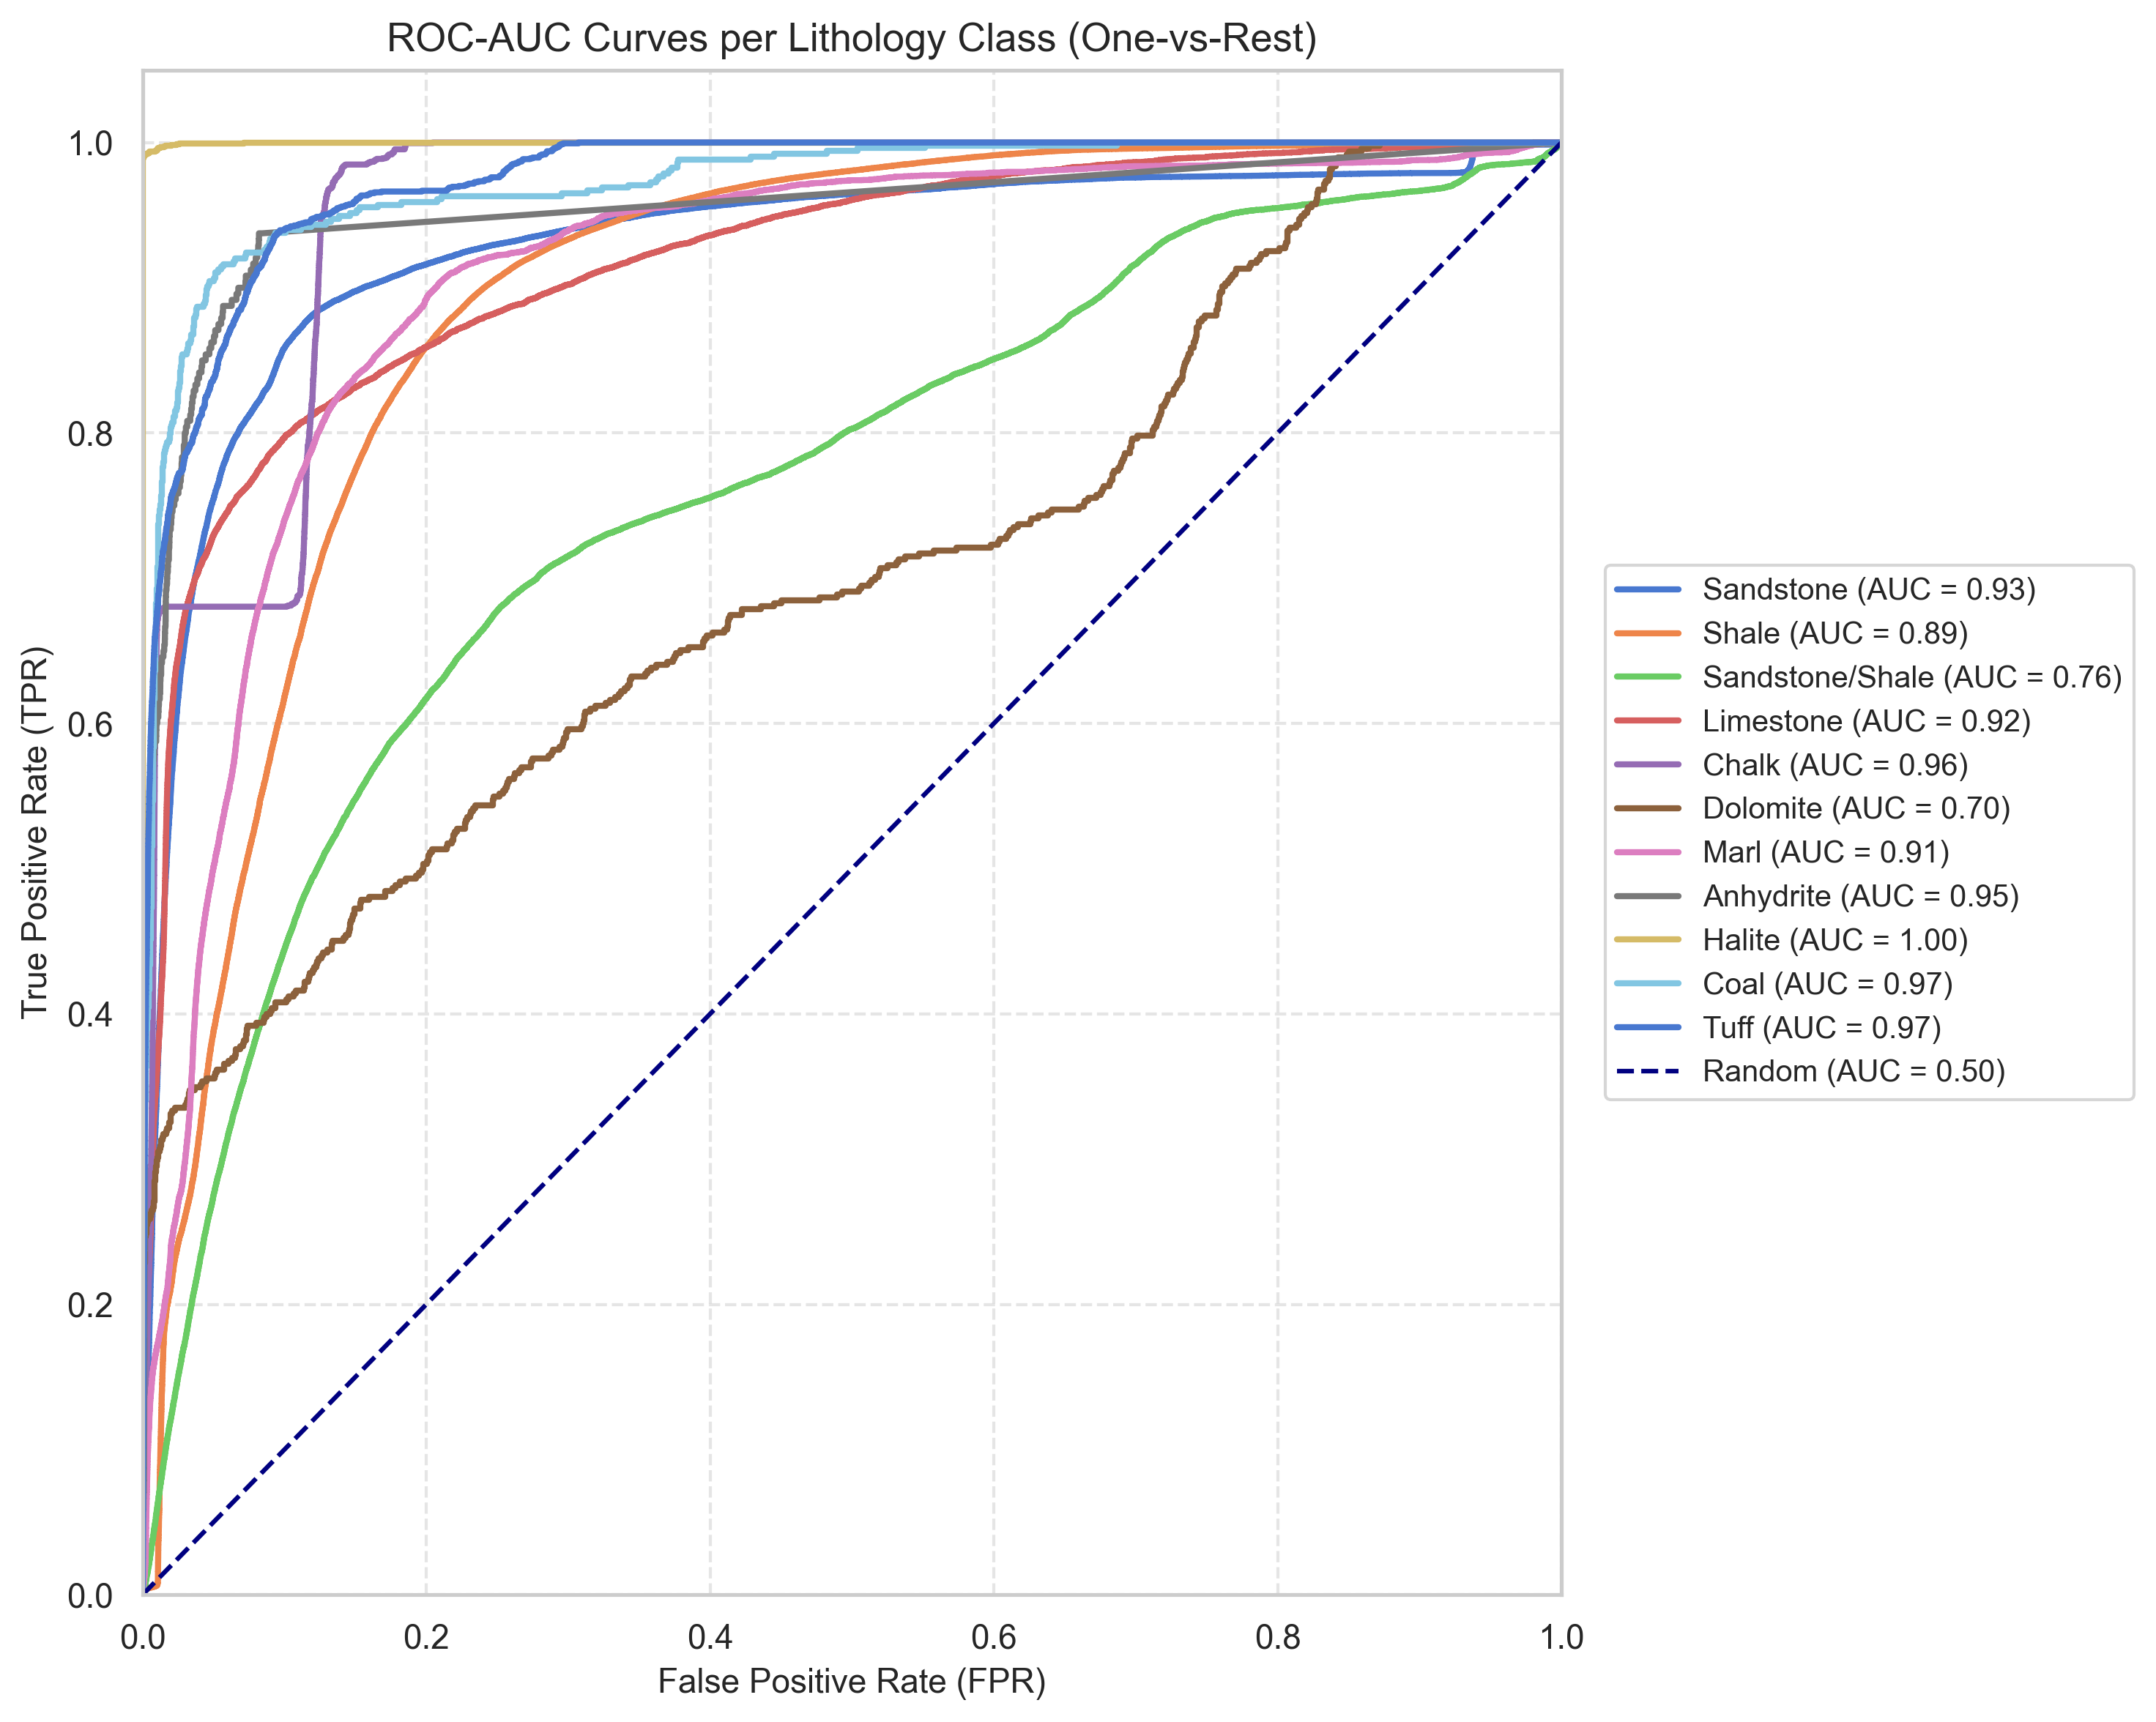

In [3]:
from src.models.baseline import Baseline
from src.metrics import LithologyEvaluator

trainer = Baseline(test_size=0.2, random_state=42)
metrics = trainer.fit_eval(df)

MODEL_PATH = Path("models/baseline_sgd.joblib")
trainer.save(MODEL_PATH)

val_preds = trainer.predict(trainer.X_val)
val_probs = trainer.predict_proba(trainer.X_val)
classes = trainer.pipeline.classes_

evaluator = LithologyEvaluator()
evaluator.plot_all(
    y_true=trainer.y_val,
    y_pred=val_preds,
    val_probs=val_probs,
    classes=classes,
    output_dir="reports/figures/baseline",
)

In [4]:
from src.models.rf_cb_optuna import RandomForest

trainer_rf = RandomForest(test_size=0.2, random_state=42)

metrics = trainer_rf.tune_optuna(df, n_trials=10)

trainer_rf.save("models/random_forest_optuna.joblib")

val_preds = trainer_rf.predict(trainer_rf.X_val)
val_probs = trainer_rf.predict_proba(trainer_rf.X_val)

Запуск Optuna (10 итераций) >>>

[Optuna] Лучшие найденные параметры:
  n_estimators: 200
  max_depth: 38
  min_samples_split: 11
  min_samples_leaf: 7
  max_features: sqrt
  class_weight: None
[Optuna] Лучший Validation F1 Weighted: 0.7438

Обучение финальной модели RandomForest >>>

Отчет по классификации (Validation):
              precision    recall  f1-score   support

       30000       0.74      0.75      0.75     37982
       65000       0.82      0.93      0.87    176056
       65030       0.40      0.17      0.24     29272
       70000       0.64      0.65      0.65     12431
       70032       0.16      0.02      0.04      2575
       74000       0.00      0.00      0.00       495
       80000       0.47      0.29      0.36     10940
       86000       0.62      0.32      0.42       240
       88000       0.98      0.87      0.92      3899
       90000       0.72      0.46      0.56       514
       99000       0.35      0.18      0.23      1838

    accuracy               

/Users/polina/miniforge3/envs/ml_course/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/polina/miniforge3/envs/ml_course/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/polina/miniforge3/envs/ml_course/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

Модель сохранена в: models/random_forest_optuna.joblib


Матрица ошибок сохранена в: reports/figures/rf_cb_optuna/confusion_matrix.png


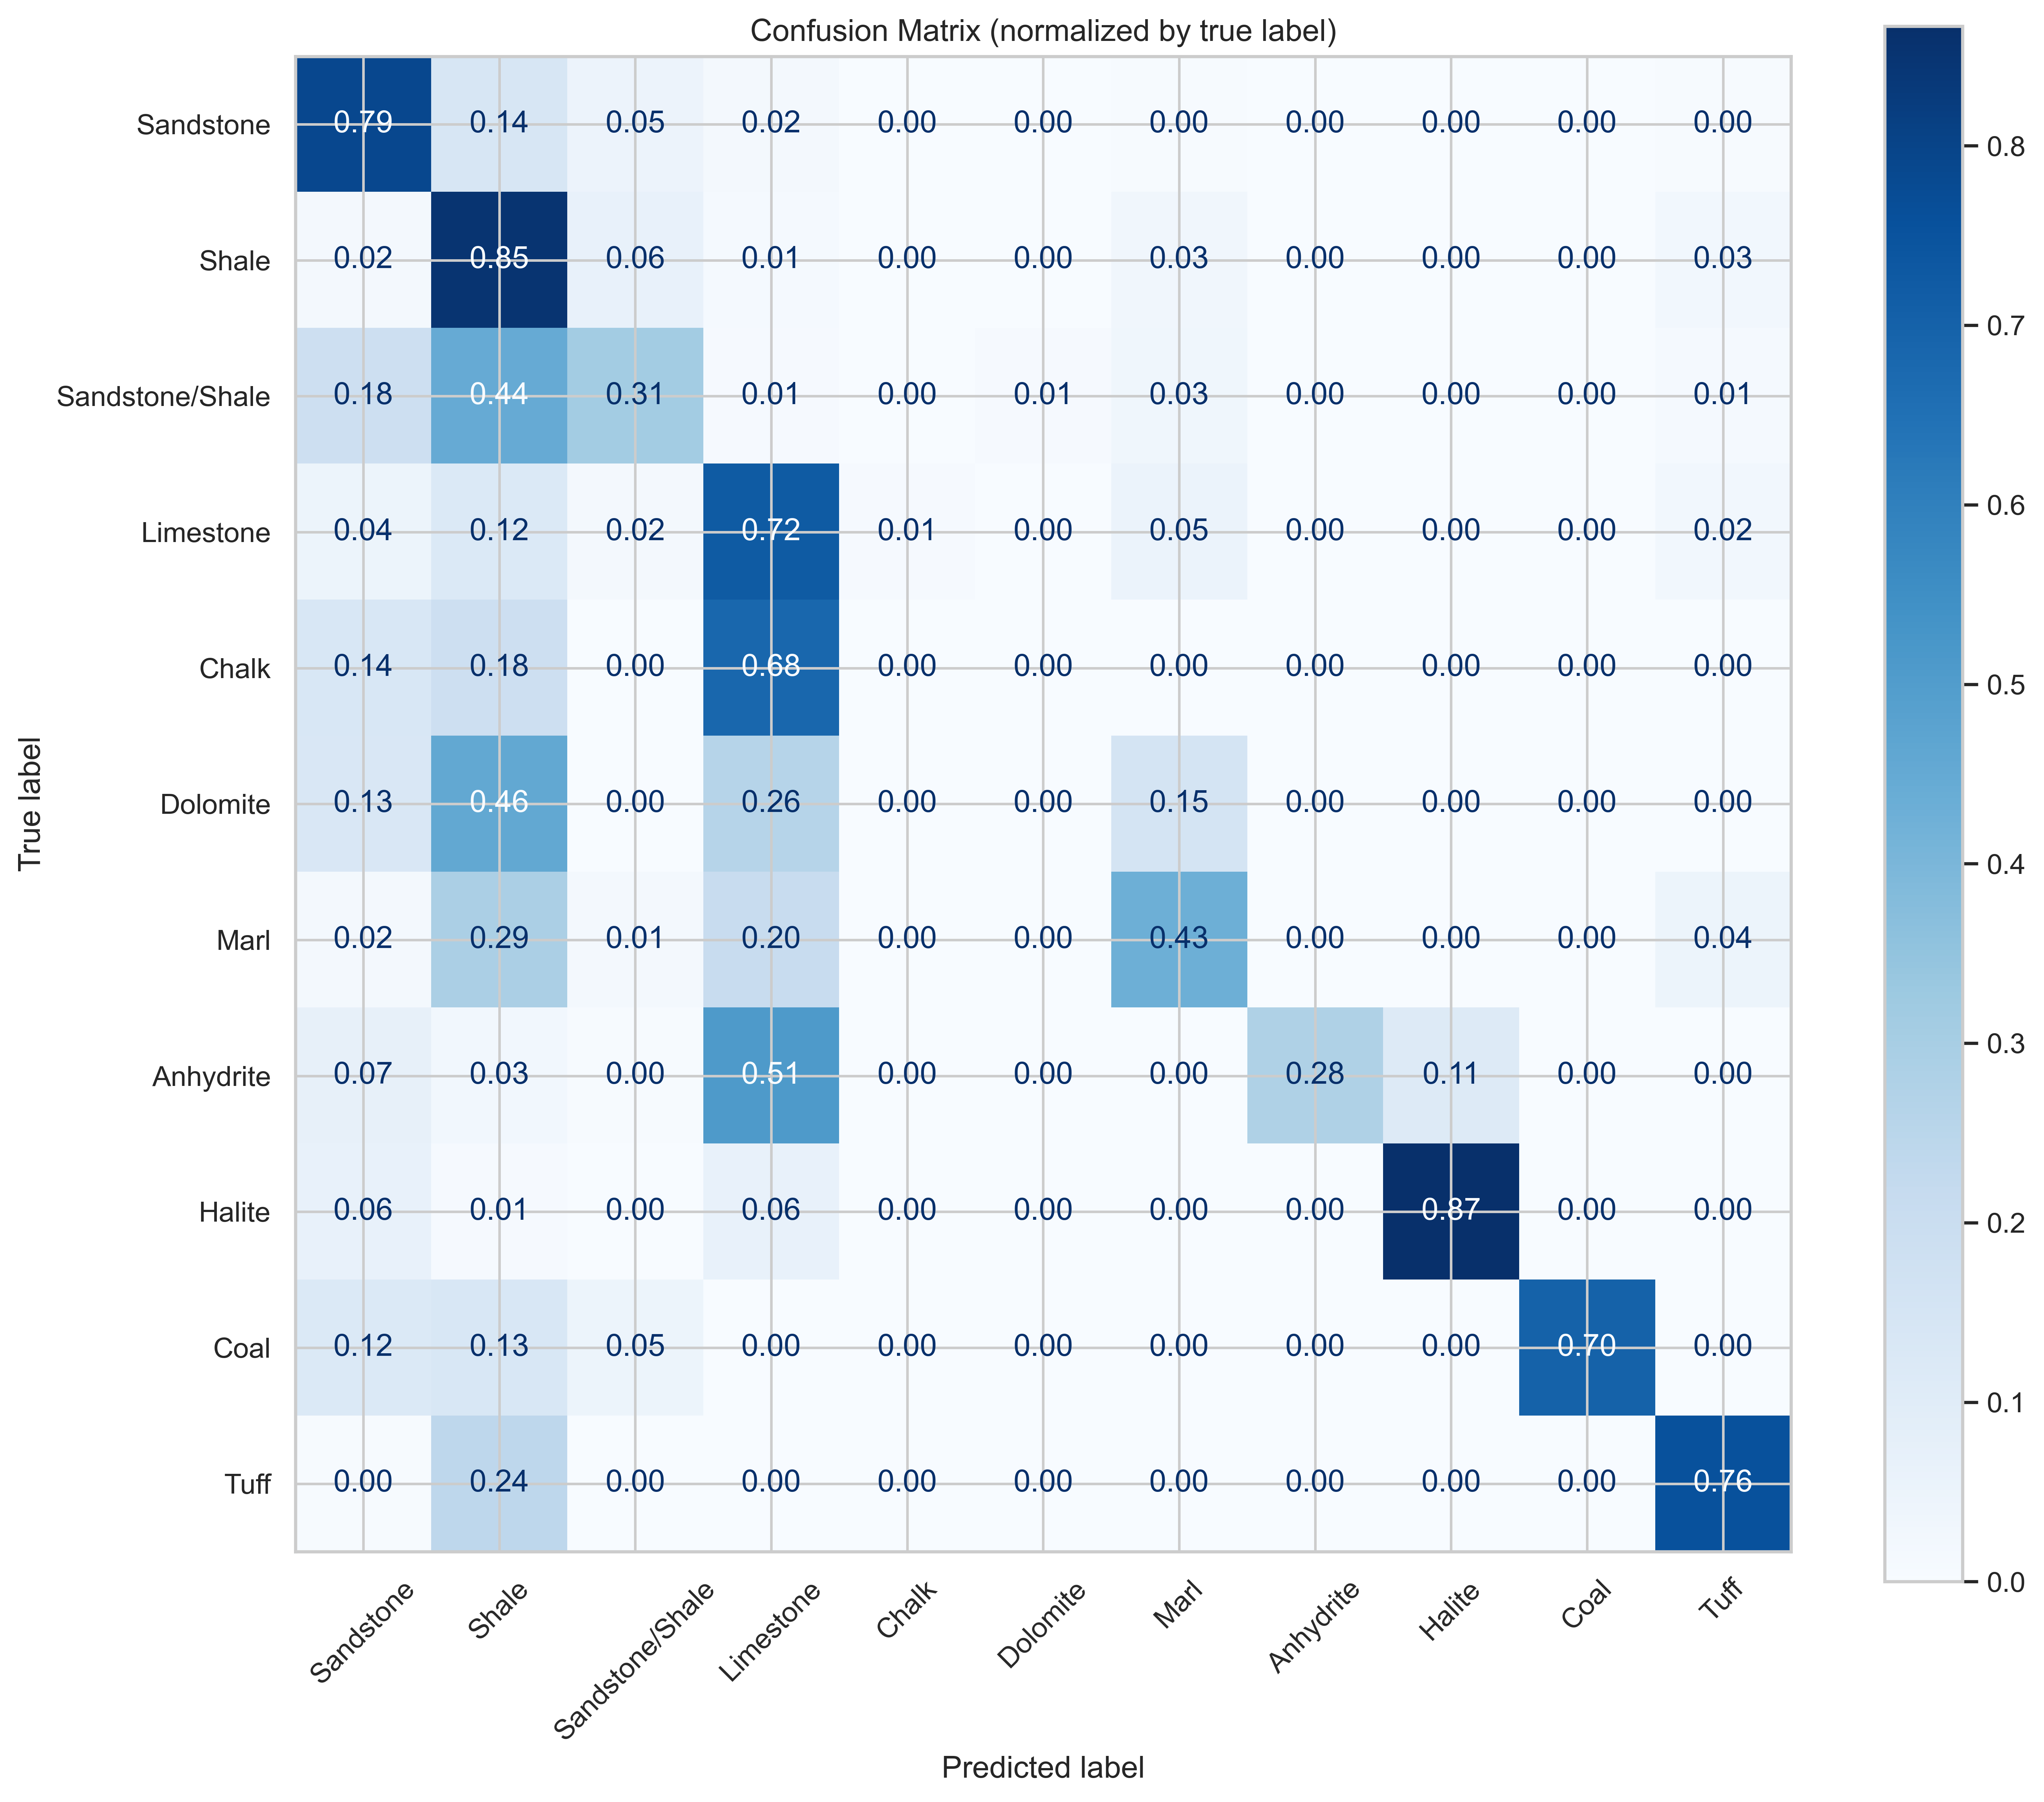

ROC-AUC графики сохранены в: reports/figures/rf_cb_optuna/roc_auc_curves.png


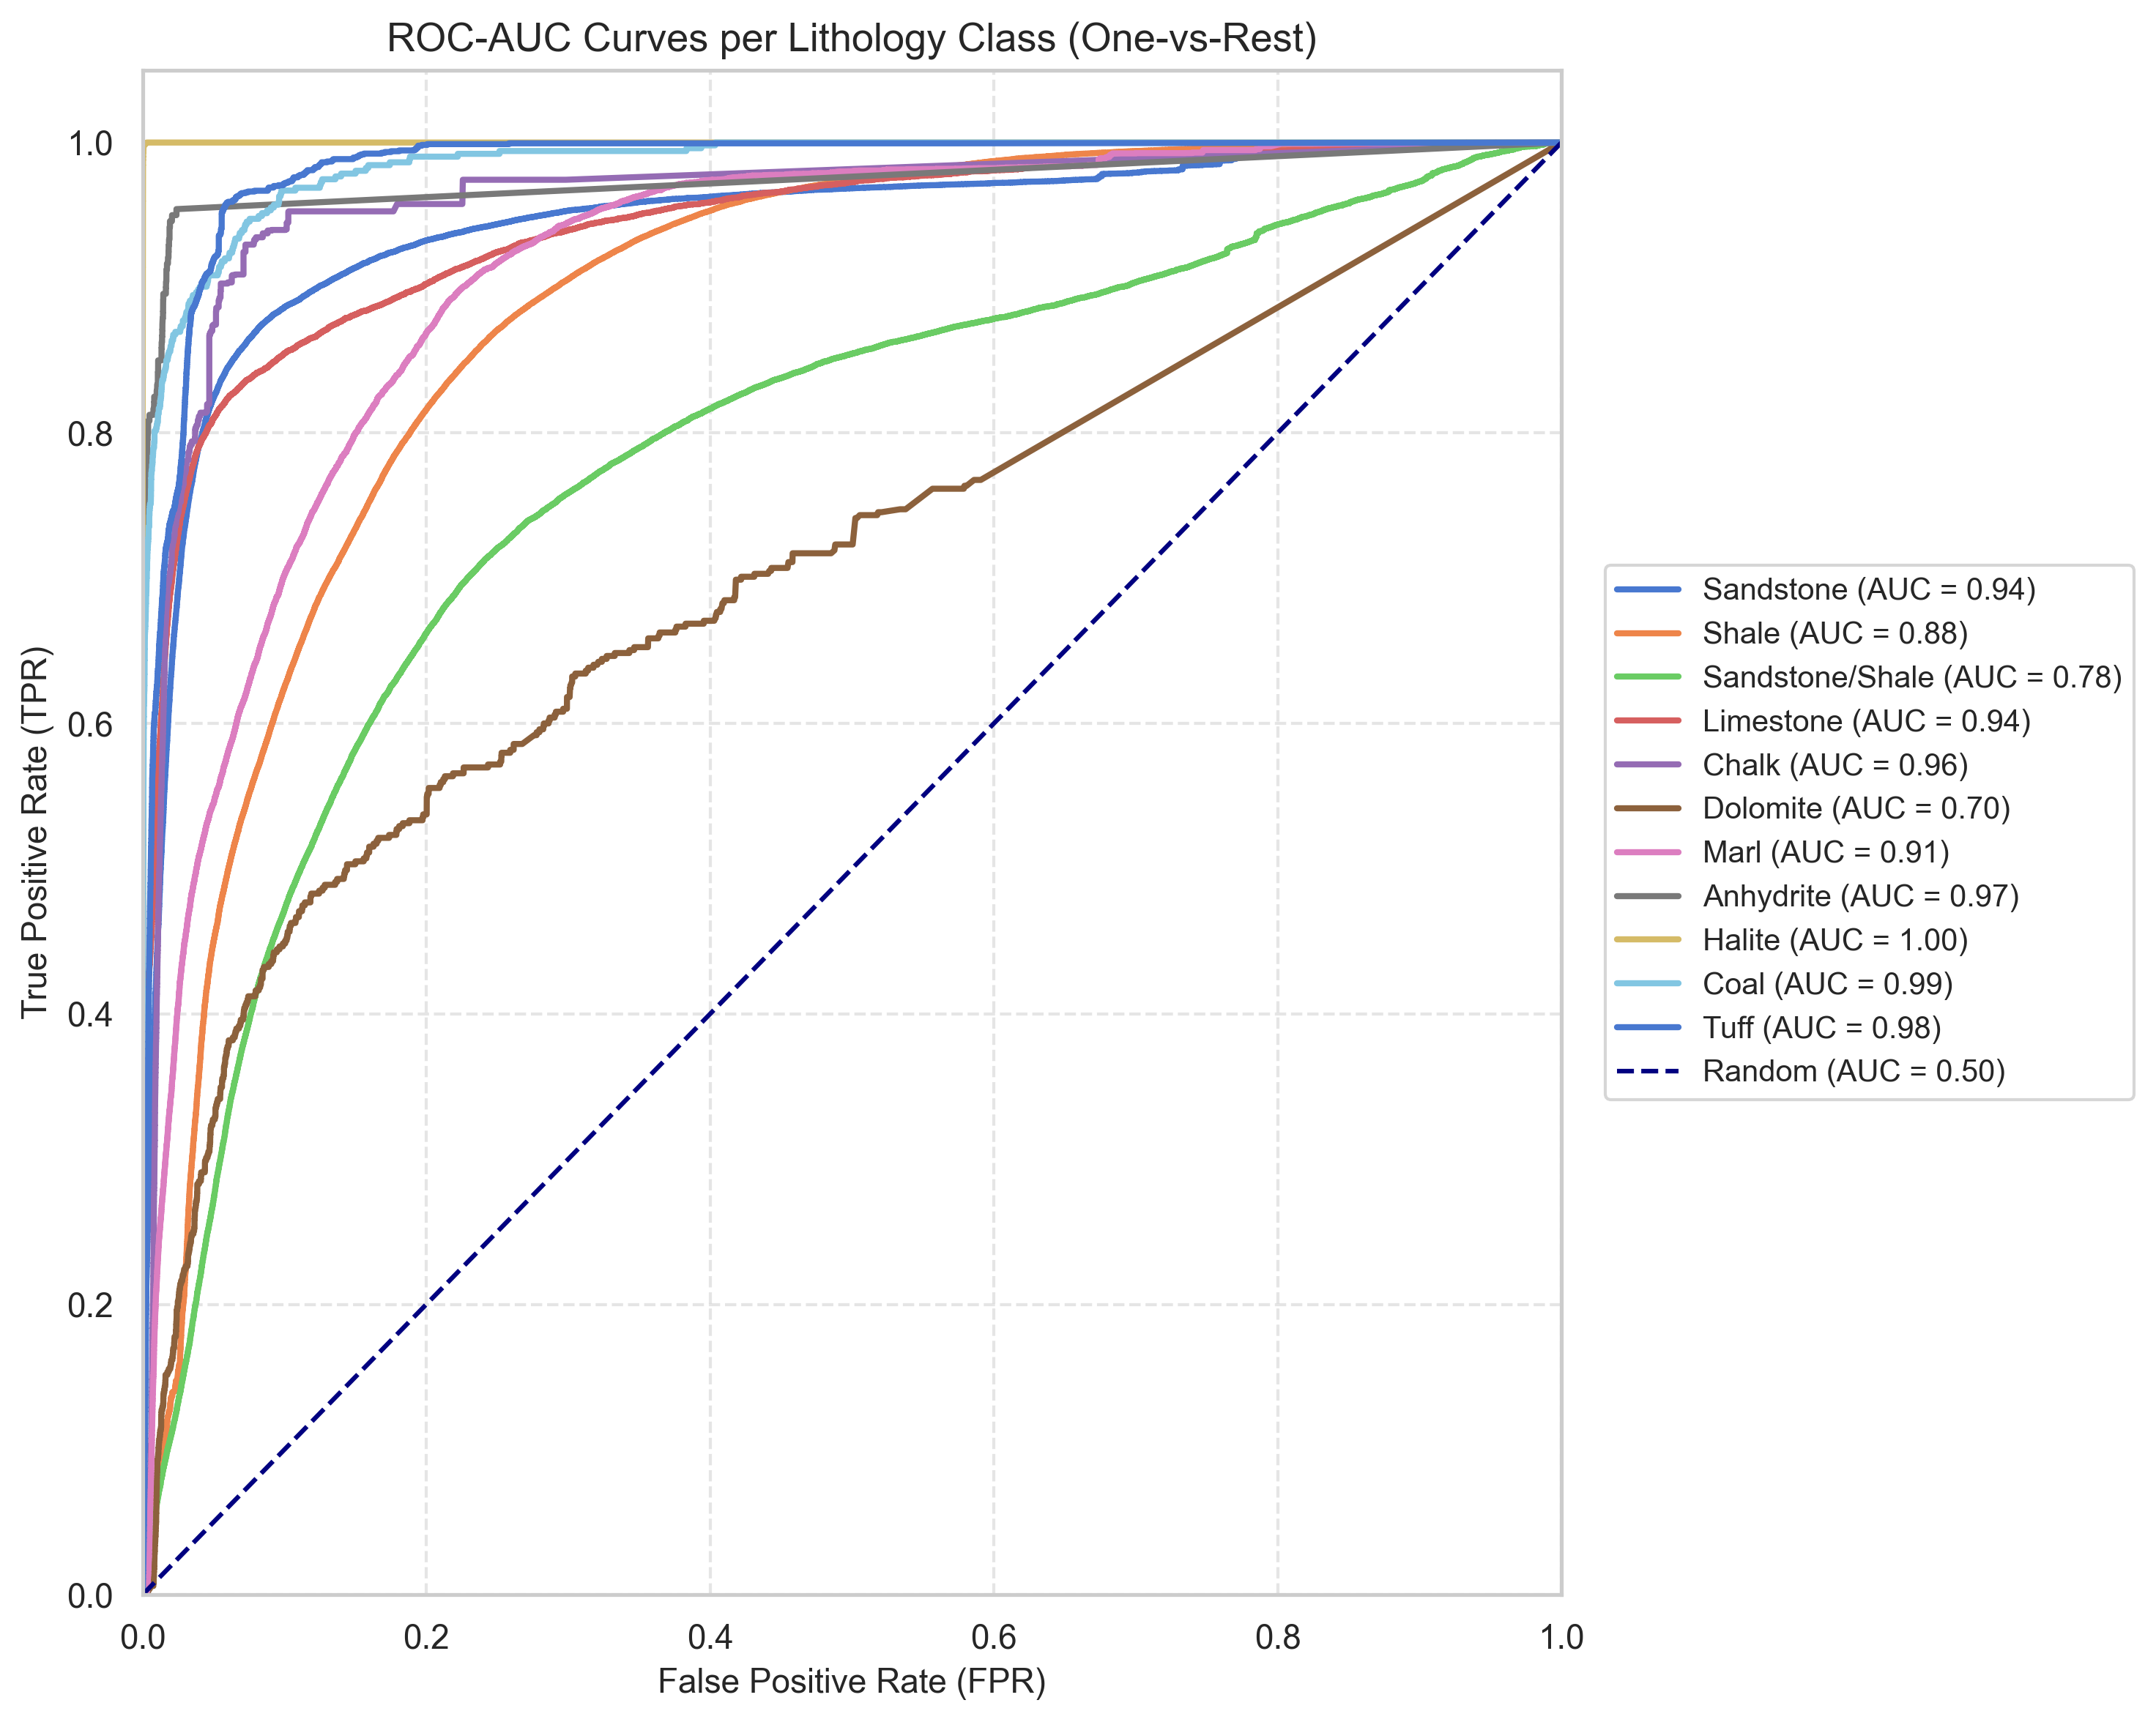

In [5]:
classes = trainer_rf.pipeline.classes_

evaluator = LithologyEvaluator()
evaluator.plot_all(
    y_true=y_val,
    y_pred=val_preds,
    val_probs=val_probs,
    classes=classes,
    output_dir="reports/figures/rf_cb_optuna",
)

Модель загружена из: models/baseline_sgd.joblib


/Users/polina/miniforge3/envs/ml_course/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/polina/miniforge3/envs/ml_course/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/polina/miniforge3/envs/ml_course/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

               precision    recall  f1-score   support

 Argillaceous       0.89      0.86      0.88    188834
     Basement       0.00      0.00      0.00         0
   Carbonates       0.53      0.66      0.58     15501
         Coal       0.07      0.76      0.13       514
   Evaporites       0.87      0.98      0.92      4139
Siliciclastic       0.73      0.68      0.70     67254

     accuracy                           0.81    276242
    macro avg       0.51      0.66      0.53    276242
 weighted avg       0.83      0.81      0.82    276242

Матрица ошибок сохранена в: /Users/polina/VSCode/ML/Lithology_project/Lithology prediction/reports/figures/grouped_baseline/confusion_matrix.png


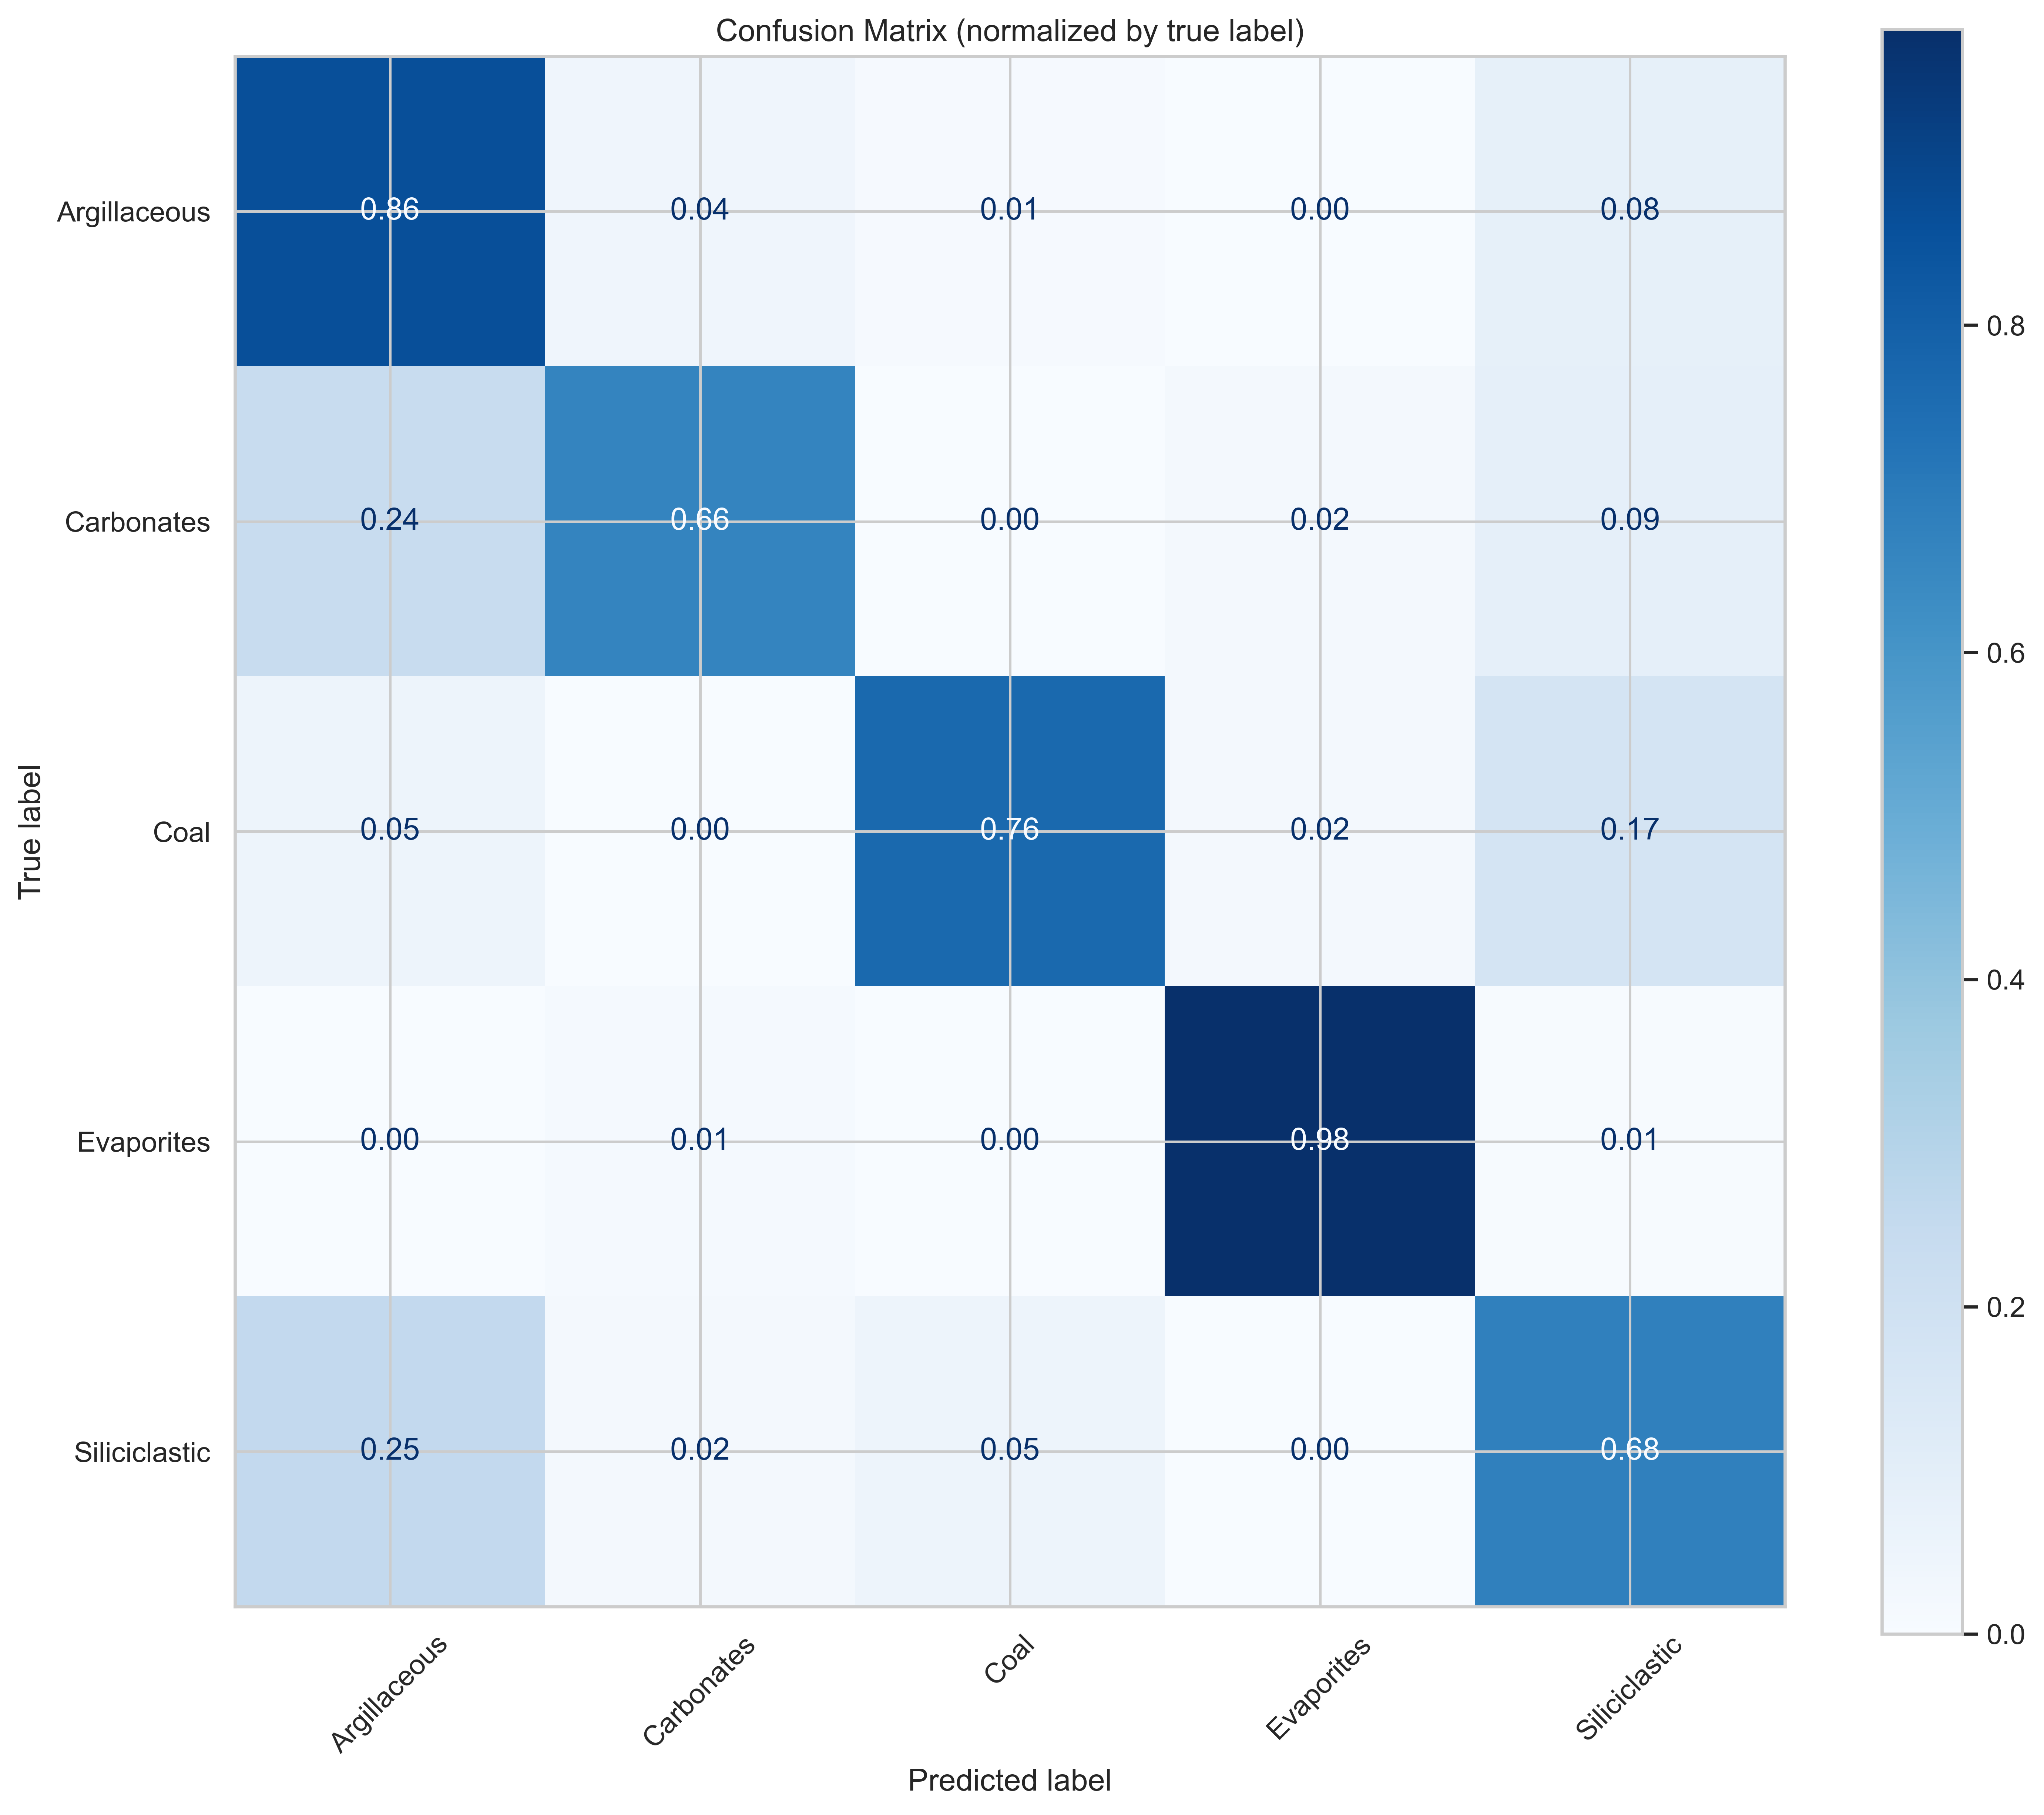

ROC-AUC графики сохранены в: /Users/polina/VSCode/ML/Lithology_project/Lithology prediction/reports/figures/grouped_baseline/roc_auc_curves.png


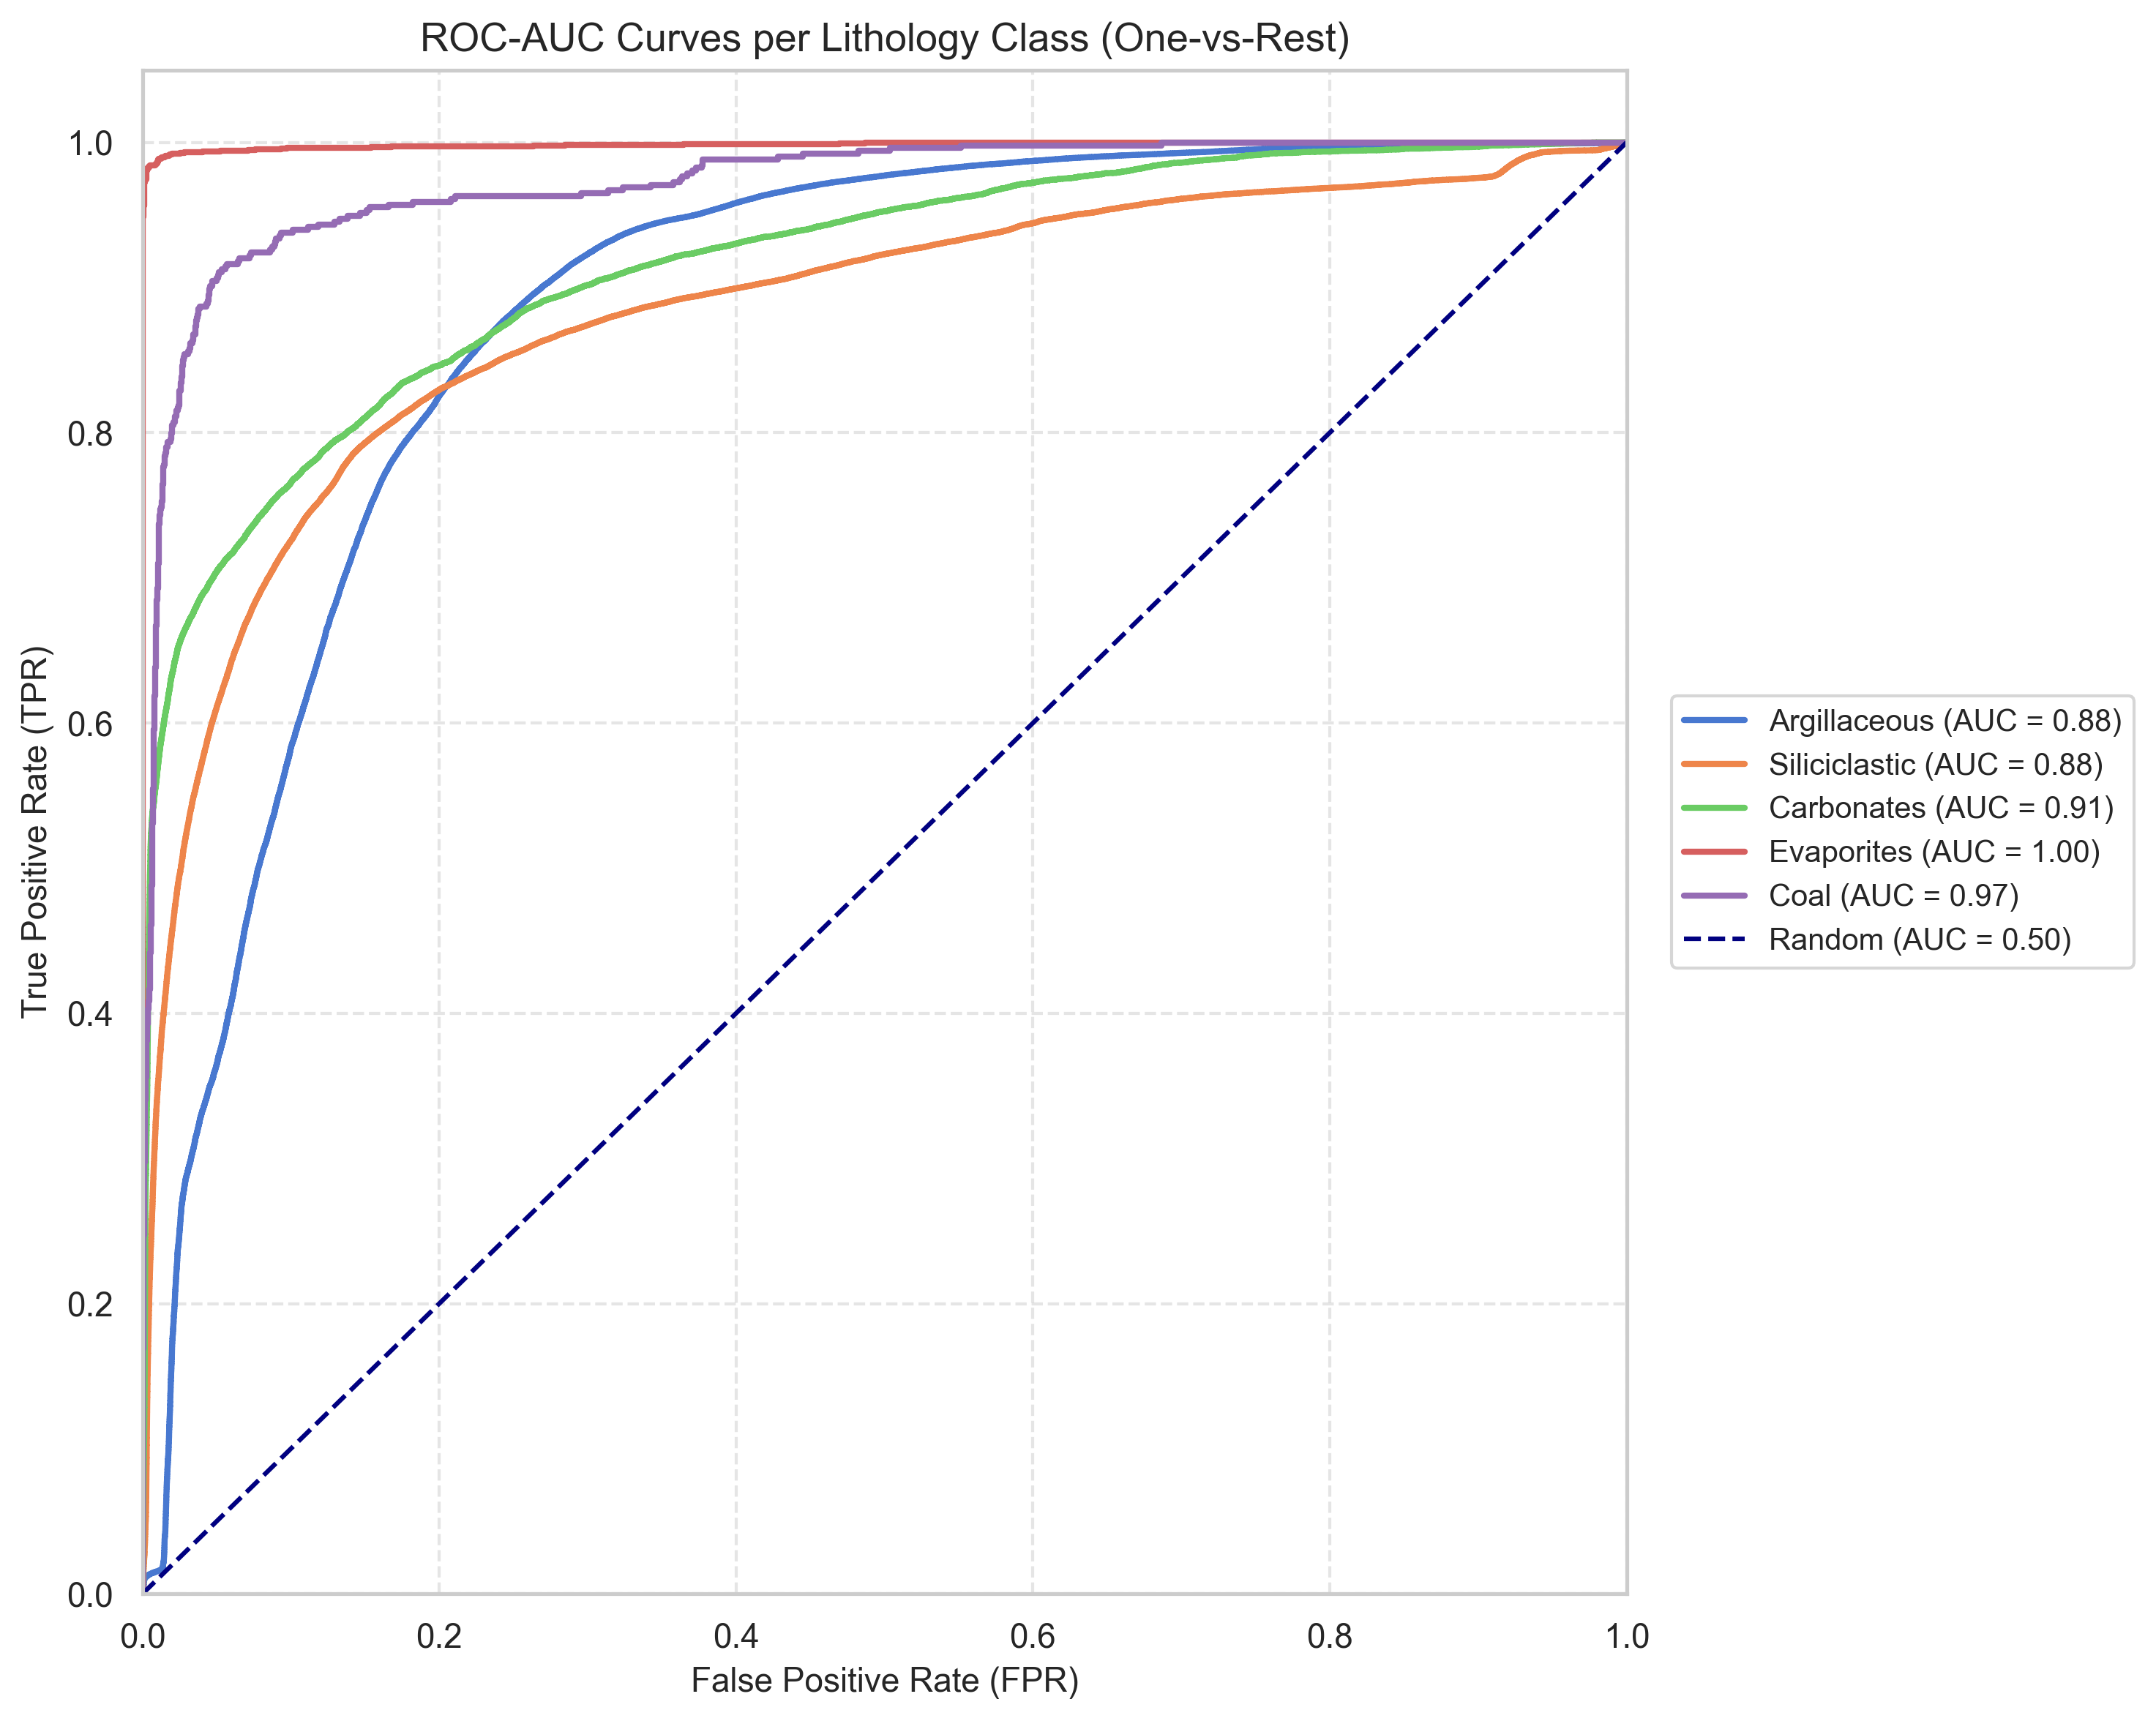

✨ Готово! Графики ROC-AUC


In [5]:
from src.class_grouper import LithologyClassGrouper

df = pd.read_parquet("/Users/polina/VSCode/ML/Lithology_project/Lithology prediction/data/processed/train_preprocessed.parquet")
df_raw = pd.read_csv('/Users/polina/VSCode/ML/Lithology_project/Lithology prediction/data/raw/train.csv', sep=';')

df['WELL'] = df_raw['WELL'].values


gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(df, groups=df['WELL']))
val_df = df.iloc[val_idx]


united_classes = {
    'Argillaceous': [65000, 80000, 99000],   # Shale, Marl, Tuff
    'Siliciclastic': [30000, 65030],         # Sandstone, Sandstone/Shale
    'Carbonates': [70000, 70032, 74000],     # Limestone, Chalk, Dolomite
    'Evaporites': [86000, 88000],            # Anhydrite, Halite
    'Coal': 90000,                           # Coal
    'Basement': 93000                        # Basement
}

grouper = LithologyClassGrouper(united_classes)
df_grouped = grouper.transform(val_df, target_col='FORCE_2020_LITHOFACIES_LITHOLOGY')
y_test_grouped = df_grouped['FORCE_2020_LITHOFACIES_LITHOLOGY']


MODEL_PATH = Path("models/baseline_sgd.joblib")
loaded_trainer = Baseline.load(str(MODEL_PATH))

raw_preds = loaded_trainer.predict(df_grouped)
preds_grouped = grouper.transform_series(pd.Series(raw_preds)).values
raw_probs = loaded_trainer.predict_proba(df_grouped)
model_classes = loaded_trainer.pipeline.classes_


probs_df = pd.DataFrame(raw_probs, columns=model_classes)

grouped_probs_df = pd.DataFrame(index=probs_df.index)

for group_name, old_classes in united_classes.items():
    if not isinstance(old_classes, list):
        old_classes = [old_classes]
    
    matching_cols = [col for col in probs_df.columns if col in old_classes or str(col) in [str(c) for c in old_classes]]
    
    if matching_cols:
        grouped_probs_df[group_name] = probs_df[matching_cols].sum(axis=1)
    else:
        grouped_probs_df[group_name] = 0.0

target_classes = list(united_classes.keys())
probs_test_grouped = grouped_probs_df[target_classes].values

from sklearn.metrics import classification_report
print(classification_report(y_test_grouped, preds_grouped))

evaluator = LithologyEvaluator()
evaluator.plot_all(
    y_true=y_test_grouped,
    y_pred=preds_grouped,
    val_probs=probs_test_grouped,
    classes=target_classes,
    output_dir=str(BASE_DIR / "reports" / "figures" / "grouped_baseline"),
)

print("✨ Готово! Графики ROC-AUC")

In [6]:
import pandas as pd
from pathlib import Path
from src.class_grouper import LithologyClassGrouper
from src.models.rf_cb_optuna import RandomForest 


df = pd.read_parquet("/Users/polina/VSCode/ML/Lithology_project/Lithology prediction/data/processed/train_preprocessed.parquet")

df_raw = pd.read_csv('/Users/polina/VSCode/ML/Lithology_project/Lithology prediction/data/raw/train.csv', sep=';')

df['WELL'] = df_raw['WELL'].values


united_classes = {
    'Argillaceous': [65000, 80000, 99000],
    'Siliciclastic': [30000, 65030],
    'Carbonates': [70000, 70032, 74000],
    'Evaporites': [86000, 88000],
    'Coal': 90000,
    'Basement': 93000
}

grouper = LithologyClassGrouper(united_classes)

df_grouped = grouper.transform(df, target_col='FORCE_2020_LITHOFACIES_LITHOLOGY')


trainer_rf_grouped = RandomForest(test_size=0.2, random_state=42)
metrics = trainer_rf_grouped.tune_optuna(df_grouped, n_trials=5)


trainer_rf_grouped.save("models/random_forest_grouped_optuna.joblib")

Запуск Optuna (5 итераций) >>>

[Optuna] Лучшие найденные параметры:
  n_estimators: 100
  max_depth: 14
  min_samples_split: 19
  min_samples_leaf: 10
  max_features: log2
  class_weight: None
[Optuna] Лучший Validation F1 Weighted: 0.8421

Обучение финальной модели RandomForest >>>

Отчет по классификации (Validation):
               precision    recall  f1-score   support

 Argillaceous       0.86      0.94      0.90    188834
   Carbonates       0.87      0.59      0.70     15501
         Coal       0.88      0.35      0.50       514
   Evaporites       0.99      0.83      0.90      4139
Siliciclastic       0.77      0.66      0.71     67254

     accuracy                           0.85    276242
    macro avg       0.87      0.67      0.74    276242
 weighted avg       0.84      0.85      0.84    276242

Модель сохранена в: models/random_forest_grouped_optuna.joblib


Матрица ошибок сохранена в: reports/figures/grouped_rf/confusion_matrix.png


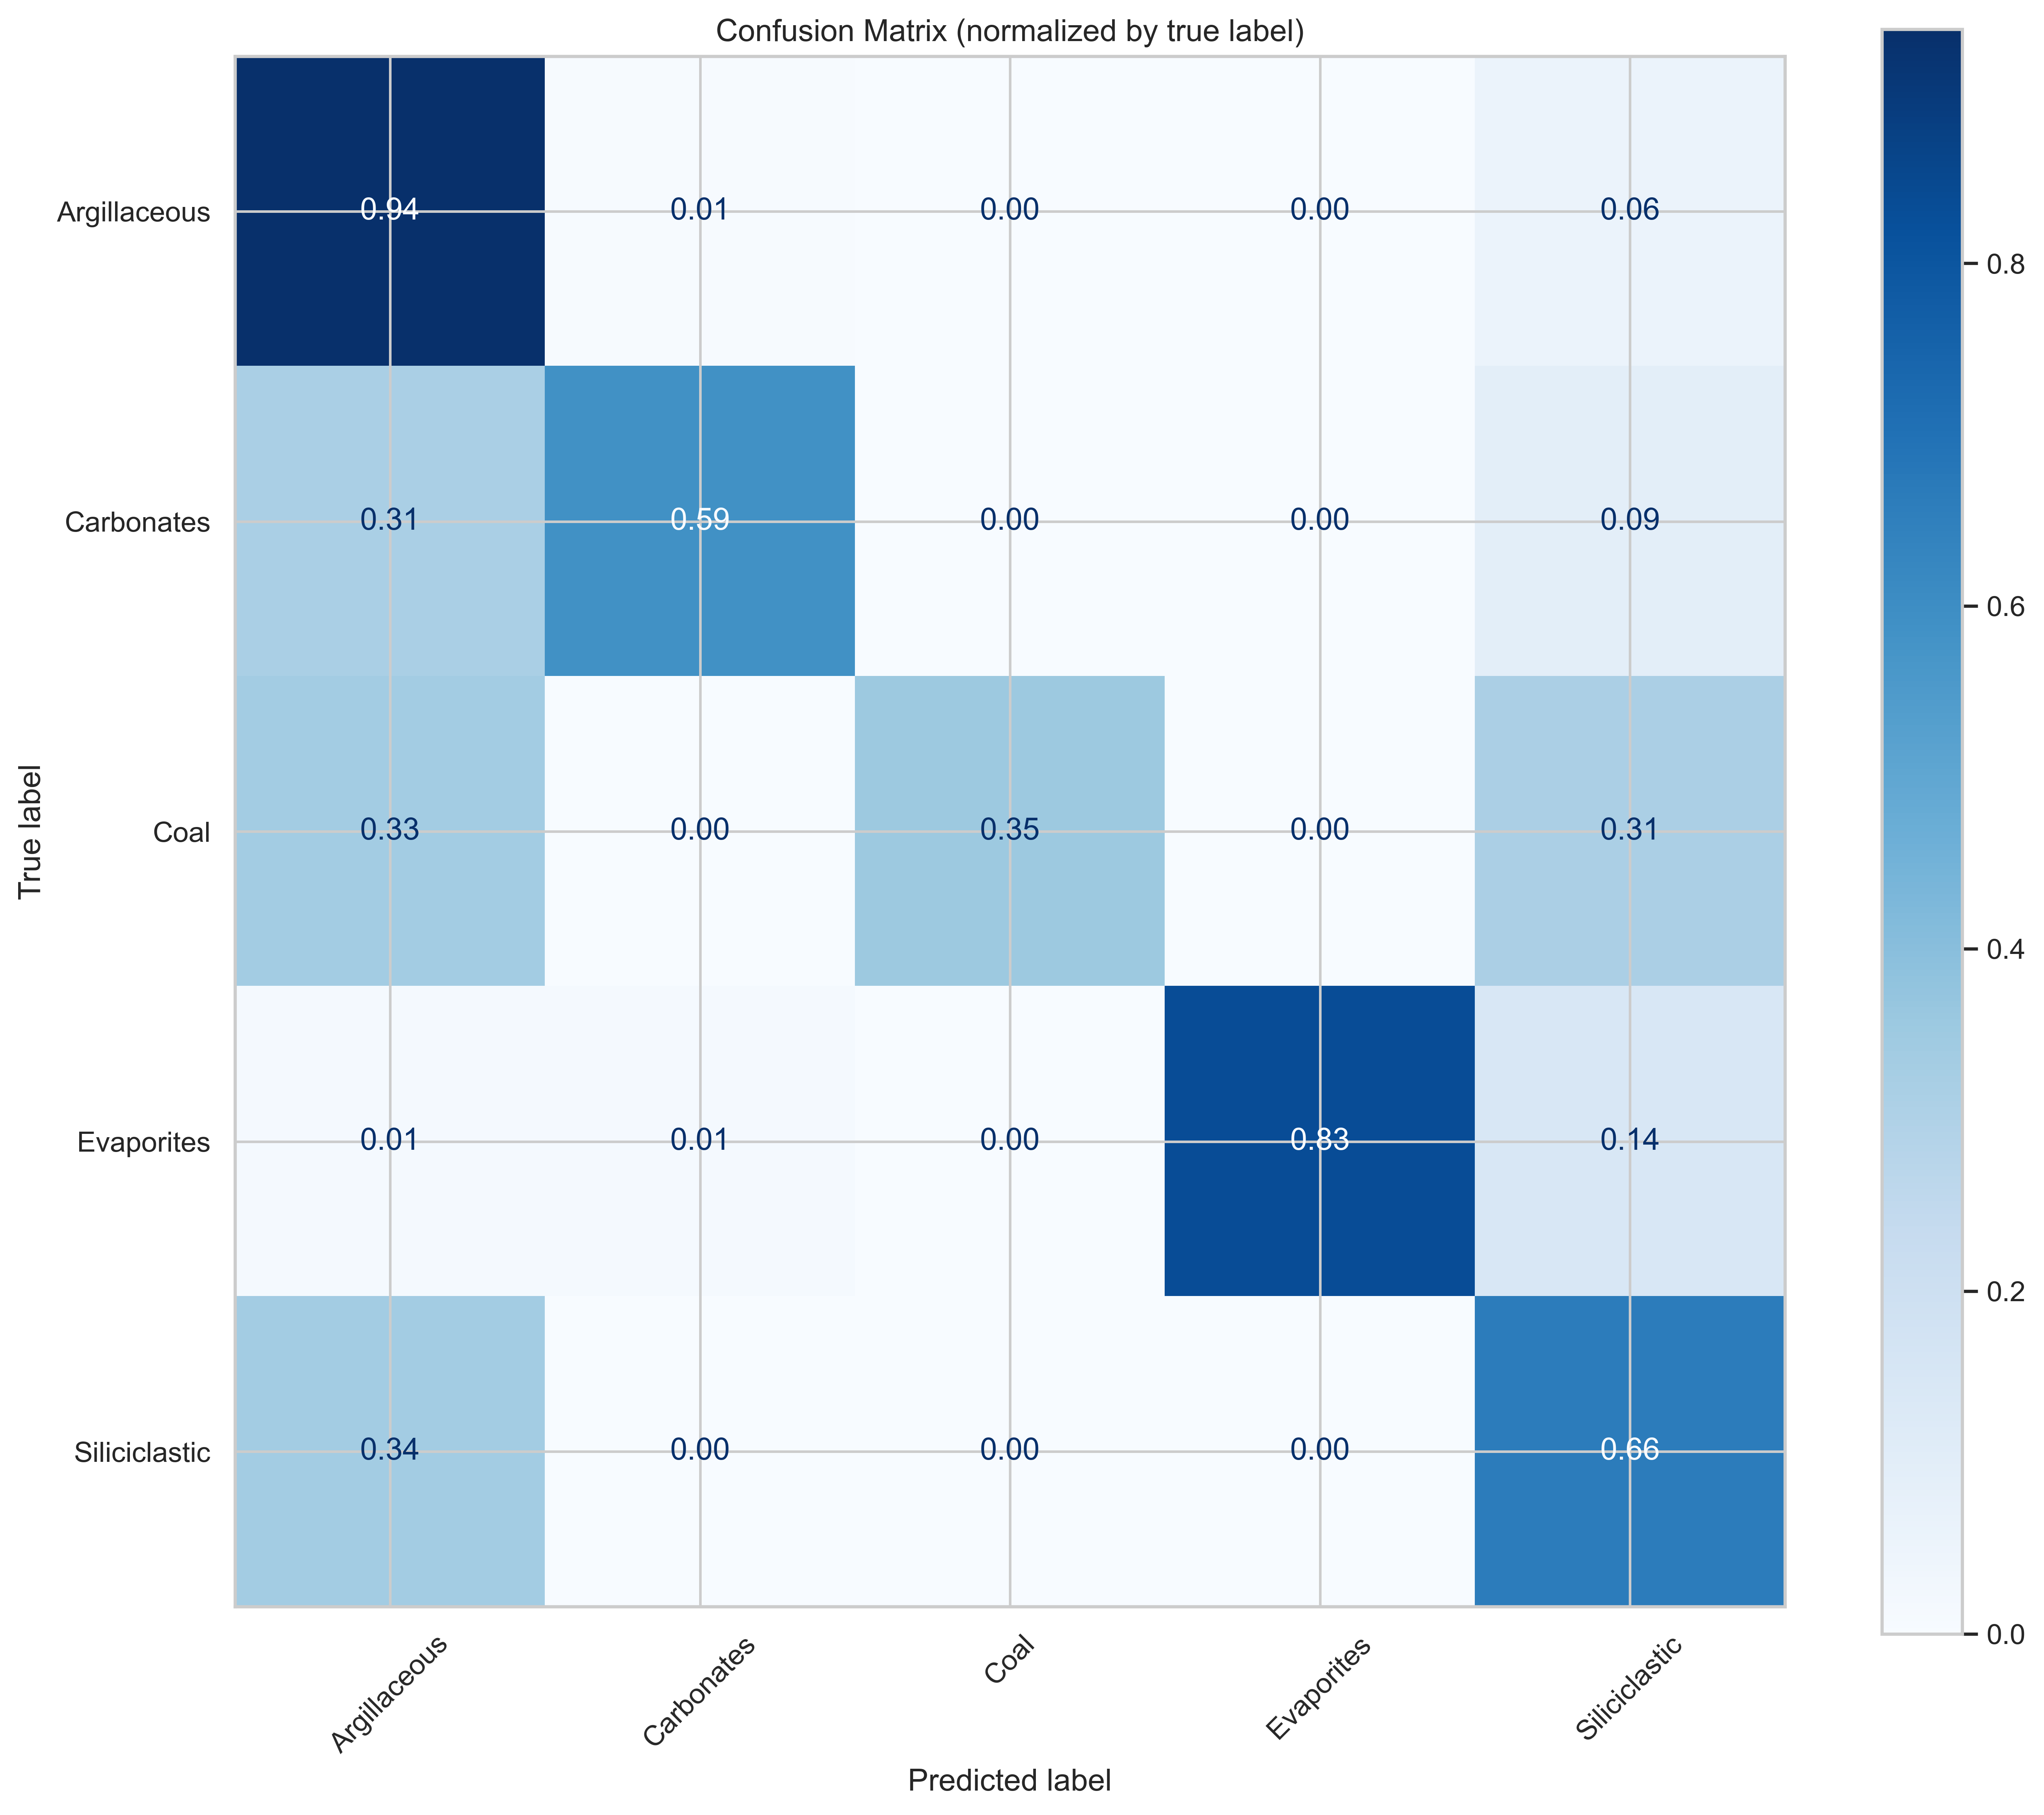

ROC-AUC графики сохранены в: reports/figures/grouped_rf/roc_auc_curves.png


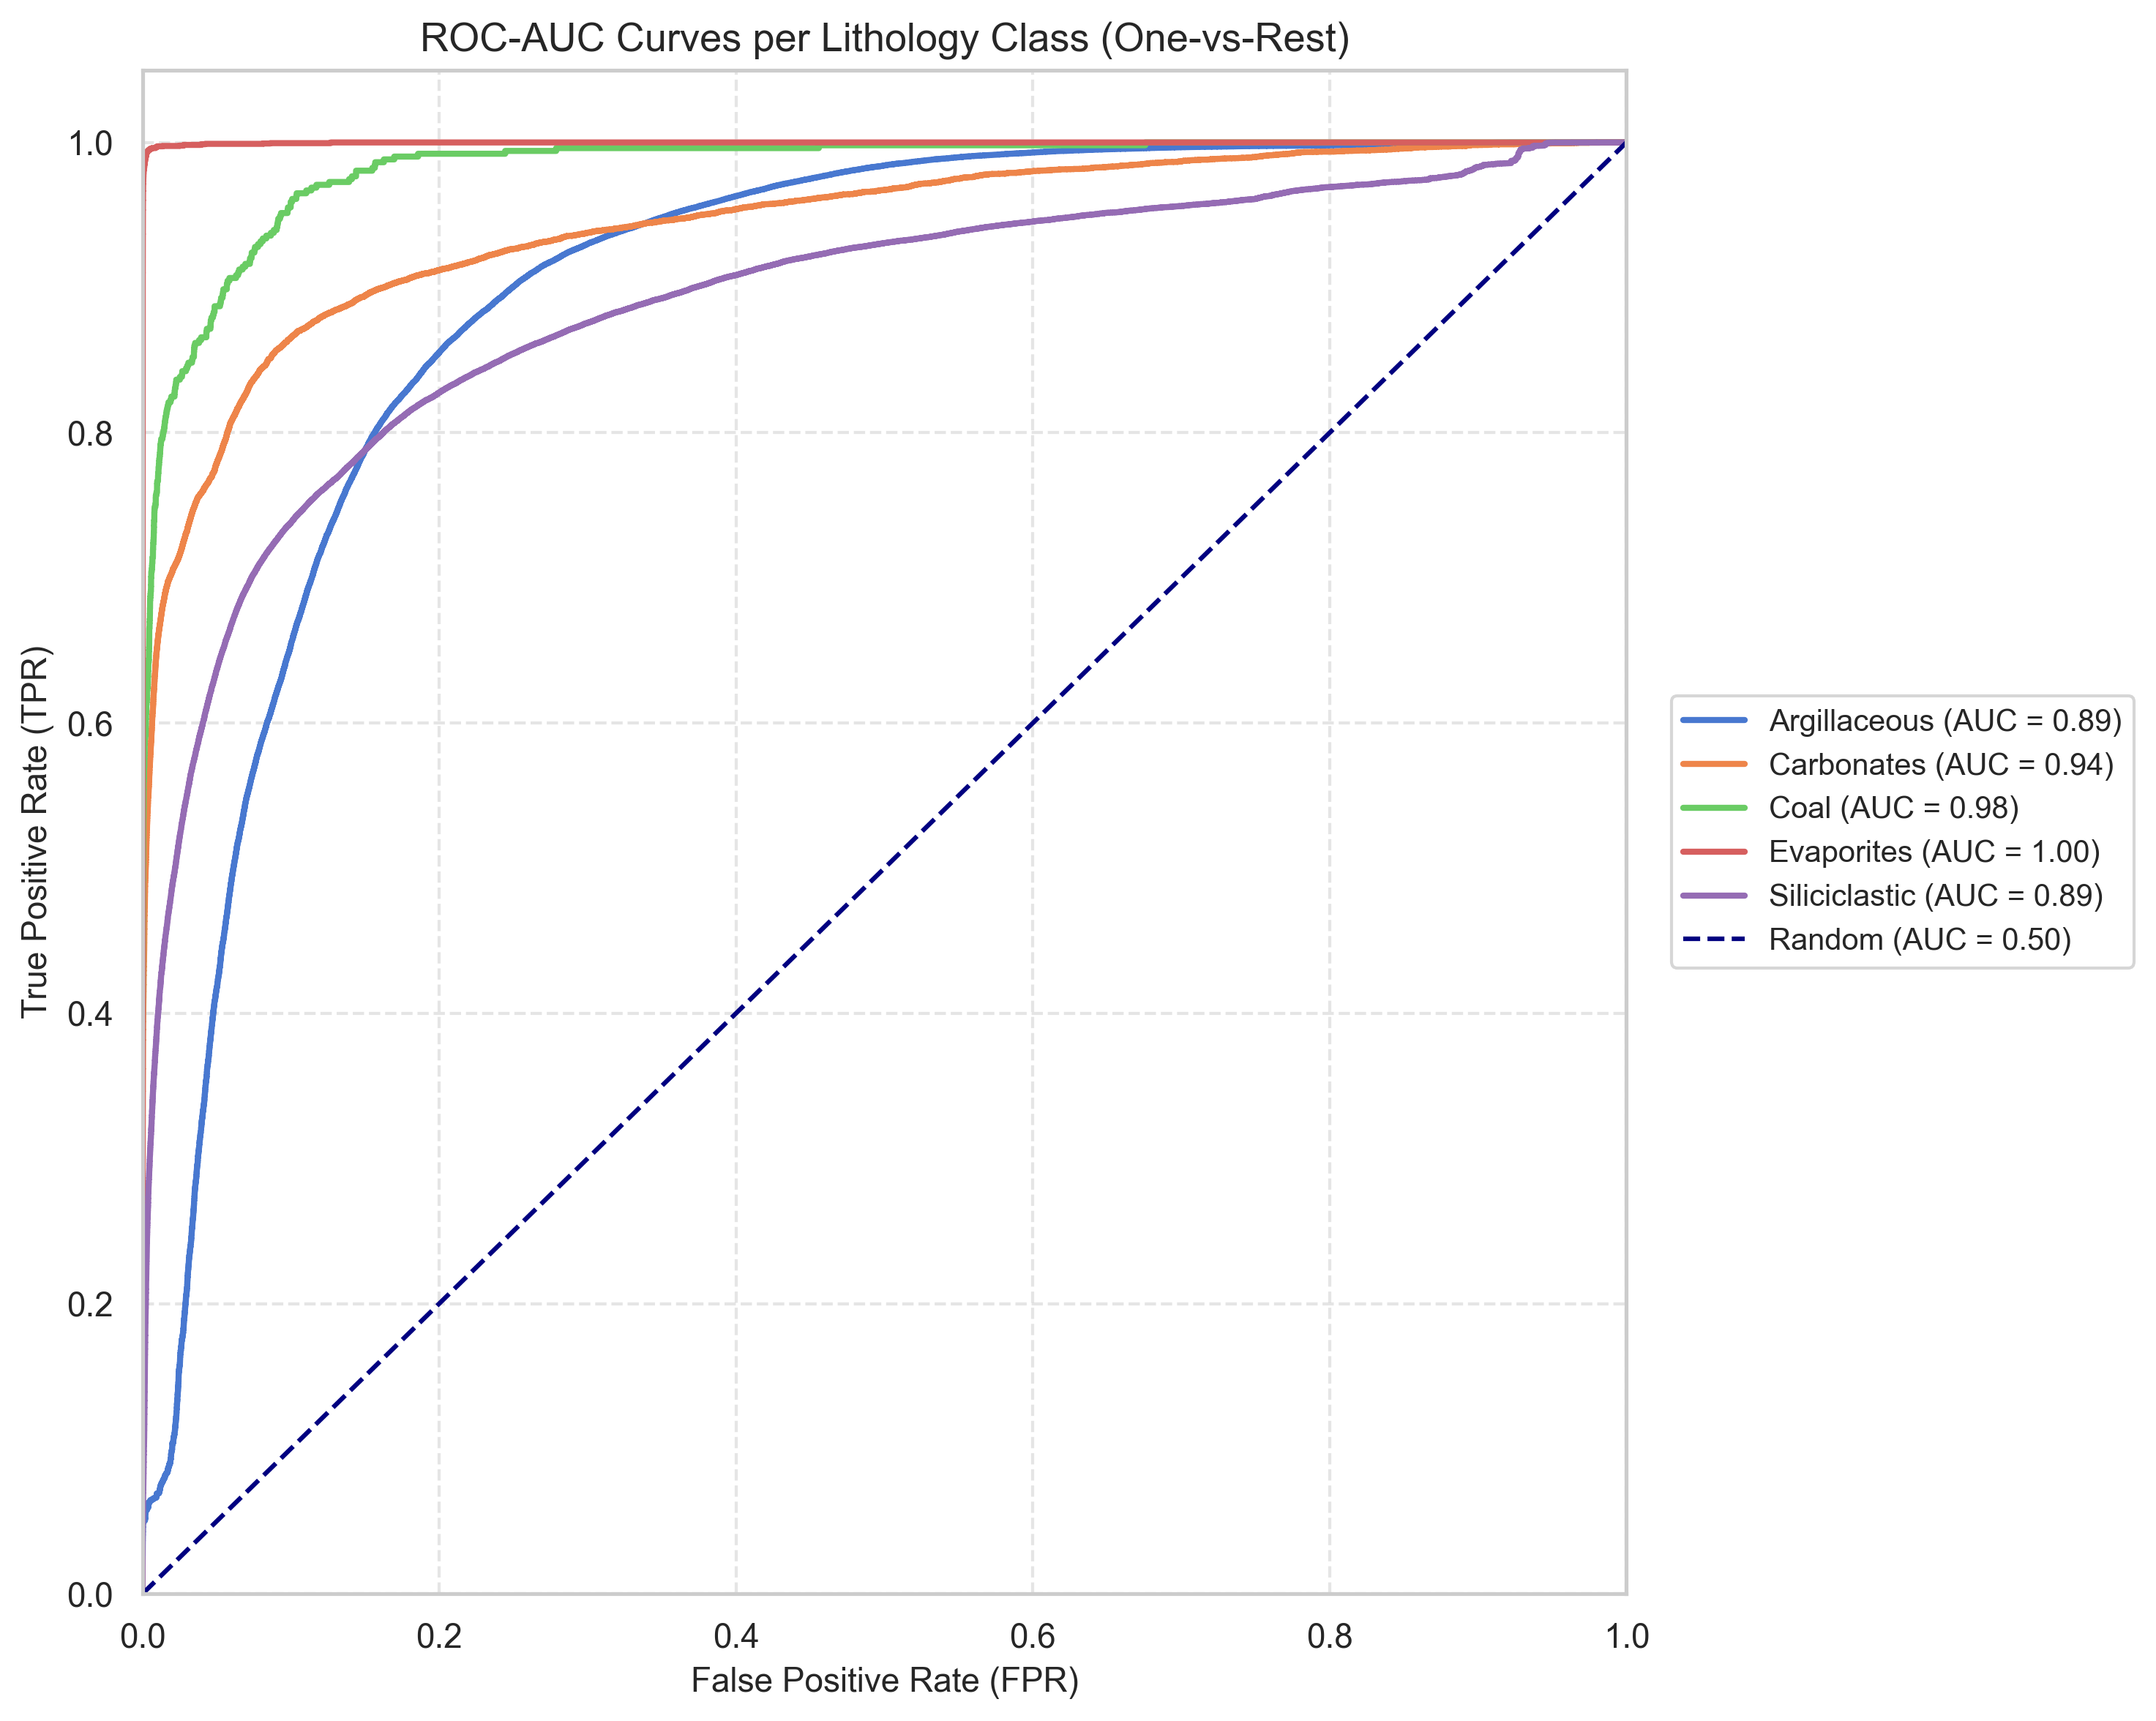

In [7]:
val_preds = trainer_rf_grouped.predict(trainer_rf_grouped.X_val)
val_probs = trainer_rf_grouped.predict_proba(trainer_rf_grouped.X_val)
classes = trainer_rf_grouped.pipeline.classes_


evaluator = LithologyEvaluator()
evaluator.plot_all(
    y_true=trainer_rf_grouped.y_val,
    y_pred=val_preds,
    val_probs=val_probs,
    classes=classes,
    output_dir="reports/figures/grouped_rf",
)